# Regresion Basica: Predecir eficiencia de gasolina

Este libro usa el set de datos clasico [Auto MPG](https://archive.ics.uci.edu/ml/datasets/auto+mpg) y construye un modelo para predecir el consumo de vehiculos de 1970 y 1980. Para hacer esto proveeremos el modelo con una descripcion de muchos automoviles de ese periodo. Esta descripcion incluye atributos como: Cilindros, desplazamiento, potencia y peso.

El objetivo de este ejercicio es predecir el target miles per galon (MPG), que vendría a representar las millas por galón de combustible.

Este ejemplo usa el API `tf.keras` , revise [Esta Guia](https://www.tensorflow.org/guide/keras) para obtener mas detalles.

In [93]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from tensorflow import keras

## El set de Datos de MPG

El set de datos esta disponible de el siguiente repositorio [UCI Machine Learning Repository](https://archive.ics.uci.edu/ml/).

### Obtenga los datos
Primero descargue el set de datos.
keras.utils.get_file("auto-mpg.data", "https://archive.ics.uci.edu/ml/machine-learning-databases/auto-mpg/auto-mpg.data")

In [94]:
data = keras.utils.get_file("auto-mpg.data", "https://archive.ics.uci.edu/ml/machine-learning-databases/auto-mpg/auto-mpg.data")
data

'/Users/fgoiri/.keras/datasets/auto-mpg.data'

Importelo usando pandas.

In [95]:
column_names = ["MPG", "Cylinders", "Displacement", "Horsepower", "Weight", "Acceleration", "Model Year", "Origin", "Car name"]

In [96]:
df = pd.read_csv(data, names=column_names, comment='\t',sep='\s+', skipinitialspace=True)
df.head(10)

,MPG,Cylinders,Displacement,Horsepower,Weight,Acceleration,Model Year,Origin,Car name
0,18.0,8,307.0,130.0,3504.0,12.0,70,1,chevrolet chevelle malibu
1,15.0,8,350.0,165.0,3693.0,11.5,70,1,buick skylark 320
2,18.0,8,318.0,150.0,3436.0,11.0,70,1,plymouth satellite
3,16.0,8,304.0,150.0,3433.0,12.0,70,1,amc rebel sst
4,17.0,8,302.0,140.0,3449.0,10.5,70,1,ford torino
5,15.0,8,429.0,198.0,4341.0,10.0,70,1,ford galaxie 500
6,14.0,8,454.0,220.0,4354.0,9.0,70,1,chevrolet impala
7,14.0,8,440.0,215.0,4312.0,8.5,70,1,plymouth fury iii
8,14.0,8,455.0,225.0,4425.0,10.0,70,1,pontiac catalina
9,15.0,8,390.0,190.0,3850.0,8.5,70,1,amc ambassador dpl


### Limpia los datos

Trata los missings y variables categóricas

In [97]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 398 entries, 0 to 397
Data columns (total 9 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   MPG           398 non-null    float64
 1   Cylinders     398 non-null    int64  
 2   Displacement  398 non-null    float64
 3   Horsepower    398 non-null    str    
 4   Weight        398 non-null    float64
 5   Acceleration  398 non-null    float64
 6   Model Year    398 non-null    int64  
 7   Origin        398 non-null    int64  
 8   Car name      398 non-null    str    
dtypes: float64(4), int64(3), str(2)
memory usage: 28.1 KB


In [98]:
# Reemplazar '?' por NaN
df['Horsepower'] = df['Horsepower'].replace('?', np.nan)

# Cambiar horsepower de string a float
df['Horsepower'] = df['Horsepower'].astype(float)

# Arreglar missings de Horsepower usando la media
df['Horsepower'] = df['Horsepower'].fillna(df['Horsepower'].mean())

# Encoding de 'Origin'
df['Origin'] = df['Origin'].map({1: 'USA', 2: 'Europe', 3: 'Japan'})
df = pd.get_dummies(df, columns=['Origin'], prefix='', prefix_sep='')

df.info()

<class 'pandas.DataFrame'>
RangeIndex: 398 entries, 0 to 397
Data columns (total 11 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   MPG           398 non-null    float64
 1   Cylinders     398 non-null    int64  
 2   Displacement  398 non-null    float64
 3   Horsepower    398 non-null    float64
 4   Weight        398 non-null    float64
 5   Acceleration  398 non-null    float64
 6   Model Year    398 non-null    int64  
 7   Car name      398 non-null    str    
 8   Europe        398 non-null    bool   
 9   Japan         398 non-null    bool   
 10  USA           398 non-null    bool   
dtypes: bool(3), float64(5), int64(2), str(1)
memory usage: 26.2 KB


In [99]:
df.head(10)

,MPG,Cylinders,Displacement,Horsepower,Weight,Acceleration,Model Year,Car name,Europe,Japan,USA
0,18.0,8,307.0,130.0,3504.0,12.0,70,chevrolet chevelle malibu,False,False,True
1,15.0,8,350.0,165.0,3693.0,11.5,70,buick skylark 320,False,False,True
2,18.0,8,318.0,150.0,3436.0,11.0,70,plymouth satellite,False,False,True
3,16.0,8,304.0,150.0,3433.0,12.0,70,amc rebel sst,False,False,True
4,17.0,8,302.0,140.0,3449.0,10.5,70,ford torino,False,False,True
5,15.0,8,429.0,198.0,4341.0,10.0,70,ford galaxie 500,False,False,True
6,14.0,8,454.0,220.0,4354.0,9.0,70,chevrolet impala,False,False,True
7,14.0,8,440.0,215.0,4312.0,8.5,70,plymouth fury iii,False,False,True
8,14.0,8,455.0,225.0,4425.0,10.0,70,pontiac catalina,False,False,True
9,15.0,8,390.0,190.0,3850.0,8.5,70,amc ambassador dpl,False,False,True


In [100]:
# Análisis descriptivo
df.describe().T

,count,mean,std,min,25%,50%,75%,max
MPG,398.0,23.514573,7.815984,9.0,17.500,23.0,29.000,46.6
Cylinders,398.0,5.454774,1.701004,3.0,4.000,4.0,8.000,8.0
Displacement,398.0,193.425879,104.269838,68.0,104.250,148.5,262.000,455.0
Horsepower,398.0,104.469388,38.199187,46.0,76.000,95.0,125.000,230.0
Weight,398.0,2970.424623,846.841774,1613.0,2223.750,2803.5,3608.000,5140.0
Acceleration,398.0,15.568090,2.757689,8.0,13.825,15.5,17.175,24.8
Model Year,398.0,76.010050,3.697627,70.0,73.000,76.0,79.000,82.0


In [101]:
lista_marcas = df['Car name'].str.split(expand=True, n=1)[0]
lista_marcas.value_counts()
# Esta variable es una locura

0
ford             51
chevrolet        43
plymouth         31
amc              28
dodge            28
toyota           25
datsun           23
buick            17
pontiac          16
volkswagen       15
honda            13
mercury          11
oldsmobile       10
mazda            10
peugeot           8
fiat              8
audi              7
chrysler          6
volvo             6
vw                6
renault           5
saab              4
opel              4
subaru            4
chevy             3
bmw               2
maxda             2
mercedes-benz     2
cadillac          2
hi                1
toyouta           1
chevroelt         1
capri             1
mercedes          1
vokswagen         1
triumph           1
nissan            1
Name: count, dtype: int64

In [102]:
# Quito la variable Car Name:
df.drop(columns=["Car name"],inplace=True)

### Divide los datos en train y test

Ahora divida el set de datos en un set de entrenamiento y otro de pruebas. 80% para entrenamiento

Usaremos el set de pruebas en la evaluacion final de nuestro modelo.

NOTA: El resultado tienen que ser dos datasets

In [103]:
# Dividir entre train y test guardando un 20% para el test
train = df.sample(frac=0.8, random_state=42)
test = df.drop(train.index)

In [104]:
# Shape de los datos, para comprobar que se ha divido bien
print(train.shape)
print(test.shape)

(318, 10)
(80, 10)


### Inspecciona los datos

Revise rapidamente la distribucion conjunta del dataset de entrenamiento mediante un grid de gráficos

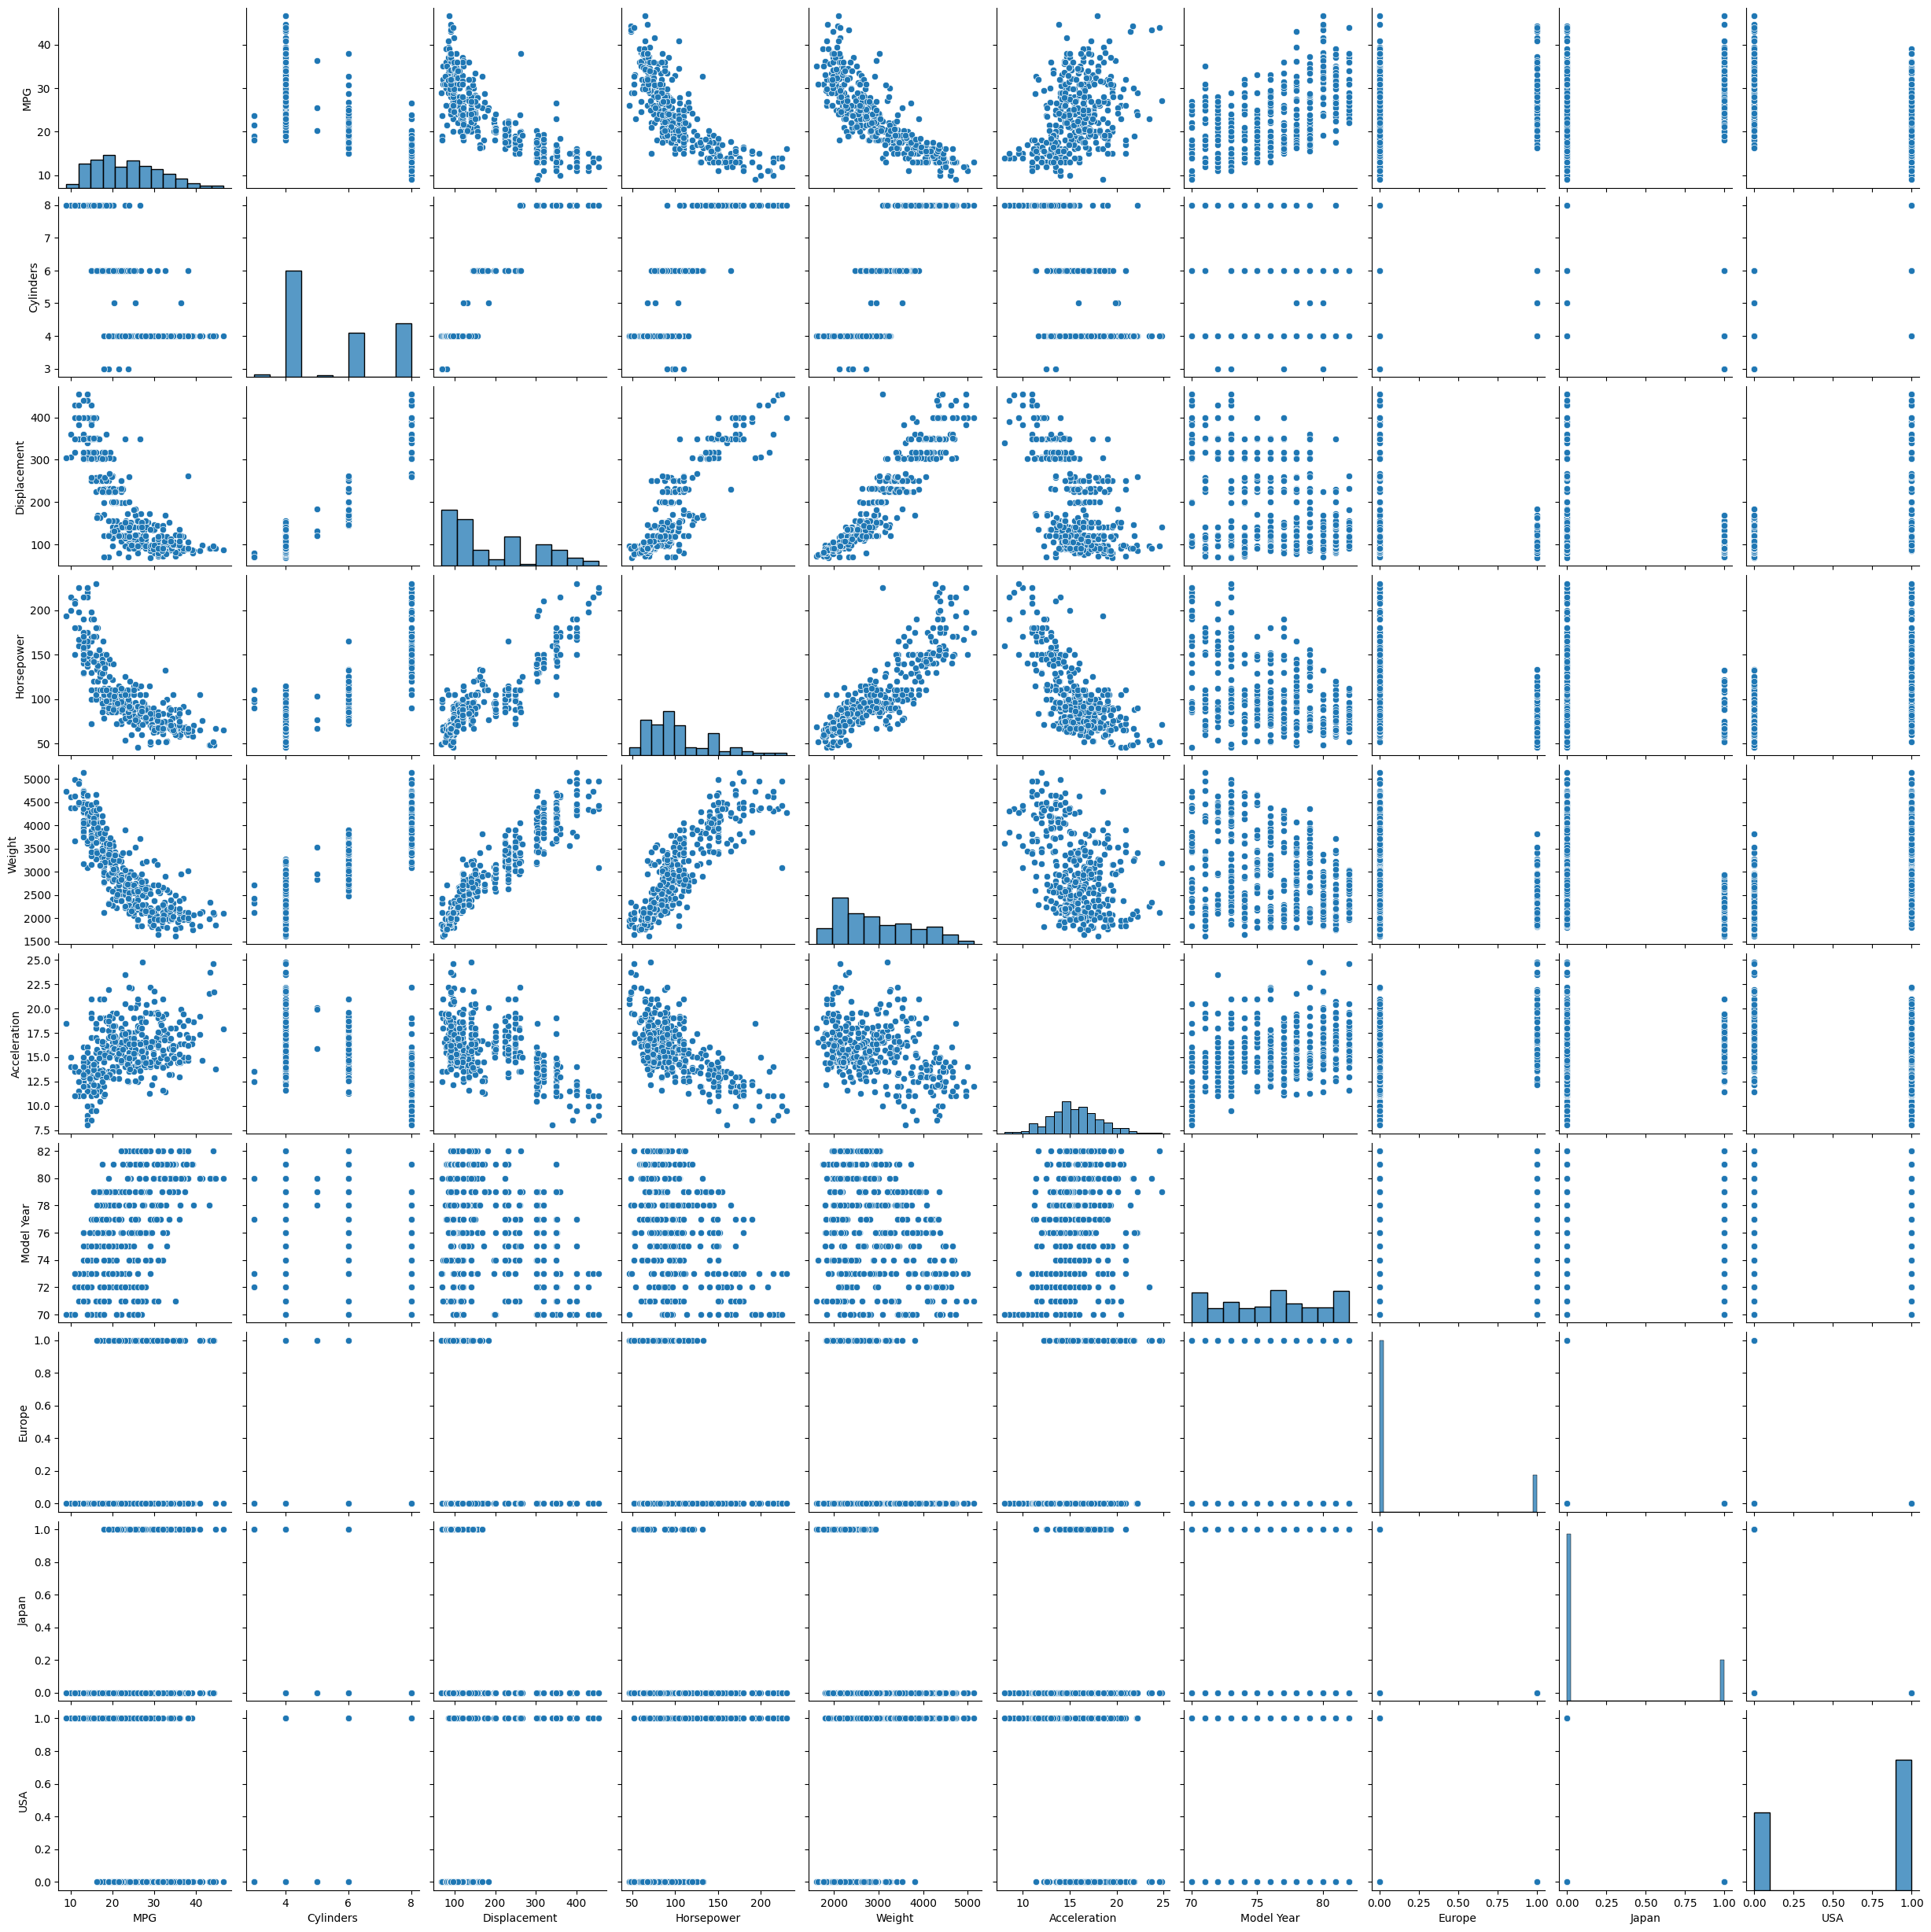

In [105]:
sns.pairplot(df);

Tambien revise las estadisticas generales:

In [106]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
MPG,398.0,23.514573,7.815984,9.0,17.500,23.0,29.000,46.6
Cylinders,398.0,5.454774,1.701004,3.0,4.000,4.0,8.000,8.0
Displacement,398.0,193.425879,104.269838,68.0,104.250,148.5,262.000,455.0
Horsepower,398.0,104.469388,38.199187,46.0,76.000,95.0,125.000,230.0
Weight,398.0,2970.424623,846.841774,1613.0,2223.750,2803.5,3608.000,5140.0
Acceleration,398.0,15.568090,2.757689,8.0,13.825,15.5,17.175,24.8
Model Year,398.0,76.010050,3.697627,70.0,73.000,76.0,79.000,82.0


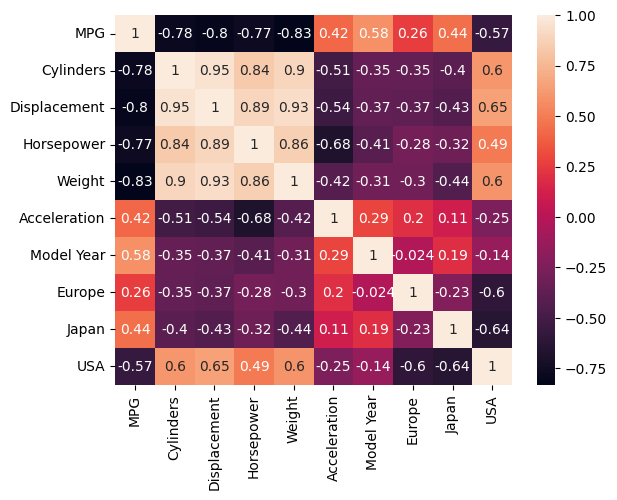

In [107]:
sns.heatmap(df.corr(numeric_only=True), annot=True);

### Separa las features del target

Separe el target de las features.

In [108]:
X_train = train.drop(columns="MPG")
X_test = test.drop(columns="MPG")
y_train = train['MPG']
y_test = test['MPG']

In [109]:
print(X_train.shape)
print(X_test.shape)
print(y_train.shape)
print(y_test.shape)

(318, 9)
(80, 9)
(318,)
(80,)


### Estandariza los datos

Es una buena práctica estandarizar funciones que utilizan diferentes escalas y rangos. Aunque el modelo podría converger sin estandarizar, dificulta el entrenamiento y hace que el modelo resultante dependa de la elección de las unidades utilizadas en la entrada.

In [110]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_std = scaler.fit_transform(X_train)
X_test_std = scaler.transform(X_test)

Estos datos estandarizados es lo que usaremos para entrenar el modelo.

## El modelo

### Construye el modelo

Construyamos nuestro modelo. Aquí, utilizaremos un modelo `secuencial` con dos capas ocultas densamente conectadas y una capa de salida que devuelve un único valor continuo.

Por tanto, tendrá tres capas. Una de entrada con activación relu. Otra hidden layer con activación relu y la de salida de regresión, que se compondrá de una única neurona. Pon las neuronas que consideres para las dos primeras capas.

Para el compile utiliza un loss='mse'.

optimizer = `tf.keras.optimizers.RMSprop(0.001)`

Y en metrics añade en una lista el `mae` y `mse`.

In [111]:
model = keras.Sequential([
    keras.layers.Dense(64, activation="relu", input_shape=X_train.shape[1:]),
    keras.layers.Dense(16,activation="relu"),
    keras.layers.Dense(1)
])

model.compile(
    loss="mse",
    optimizer= keras.optimizers.RMSprop(0.001),
    metrics=['mae','mse']
)

/Users/fgoiri/miniconda3/envs/bootcamp2/lib/python3.11/site-packages/keras/src/layers/core/dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


### Inspeccione el modelo

Use el método `.summary` para imprimir una descripción simple del modelo

In [112]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 64)             │           640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 16)             │         1,040 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,697 (6.63 KB)

 Trainable params: 1,697 (6.63 KB)

 Non-trainable params: 0 (0.00 B)

### Entrenar el modelo

Entrene el modelo para 1000 epochs y guarda los resultados del entrenamiento en una variable llamada `history`.
Emplea en el entrenamiento un 20% de los datos para validación, mediante el argumento `validation_split`.

NOTA: recuerda usar los datos normalizados.

In [114]:
early_stopping = keras.callbacks.EarlyStopping(patience=10)
history = model.fit(X_train_std, y_train, epochs=1000, validation_split=0.2, verbose=0, callbacks=[early_stopping])

Visualice el progreso de entrenamiento del modelo usando las estadísticas almacenadas en el objeto `history`.

In [115]:
history.history

{'loss': [597.707763671875,
  567.3613891601562,
  540.0836791992188,
  512.3099365234375,
  482.7620544433594,
  451.9012451171875,
  418.7174987792969,
  383.9896240234375,
  348.16998291015625,
  311.292236328125,
  273.3753356933594,
  235.44715881347656,
  198.59083557128906,
  163.93894958496094,
  132.4285125732422,
  104.29556274414062,
  80.72134399414062,
  62.52928161621094,
  48.95295333862305,
  39.20964050292969,
  32.578155517578125,
  27.877328872680664,
  24.227846145629883,
  21.41730499267578,
  19.083051681518555,
  17.229631423950195,
  15.649490356445312,
  14.460289001464844,
  13.513962745666504,
  12.518684387207031,
  11.760601043701172,
  10.975424766540527,
  10.323906898498535,
  9.857970237731934,
  9.274982452392578,
  8.902854919433594,
  8.675517082214355,
  8.284537315368652,
  8.082749366760254,
  7.806118488311768,
  7.657804012298584,
  7.454681873321533,
  7.317435264587402,
  7.198187828063965,
  7.241431713104248,
  6.973636150360107,
  6.8125634

<Axes: >

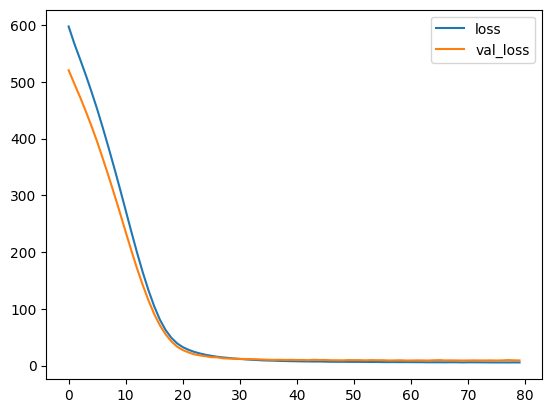

In [116]:
pd.DataFrame(history.history)[['loss','val_loss']].plot()

¿Alguna conclusión respecto a este gráfico?

El error baja rápido alrededor de las 20 epochs. No hay overfitting.

Veamos qué tan bien generaliza el modelo al usar el conjunto de **test**. Esto nos dice qué tan bien podemos esperar que el modelo prediga cuándo lo usamos en el mundo real. Utiliza el método `evaluate` con los datos de test normalizados y sus labels.

Con el método evaluate devolverá tres valores: loss, mae y mse.

Ahora prueba el modelo. Coge 10 ejemplos de test y llama a` model.predict`.

In [118]:
loss, mae, mse = model.evaluate(X_test_std, y_test, verbose=2)
print(f"\nTest MAE: {mae:.2f} MPG")

y_pred = model.predict(X_test_std[:10]) # coger 10 ejemplos
print("Predicciones:", y_pred.flatten())
print("Reales:      ", y_test[:10].values)

3/3 - 0s - 5ms/step - loss: 7.6324 - mae: 2.1546 - mse: 7.6324

Test MAE: 2.15 MPG
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step
Predicciones: [14.857253 15.357552 20.863384 23.202435 17.100872 12.606085 19.263172
 26.033651 24.887625 27.071339]
Reales:       [15. 14. 25. 24. 16. 13. 18. 23. 28. 30.]


### Haz Predicciones

Dibuja en un scatter plot las predicciones de test vs sus true labels.

In [119]:
y_pred = model.predict(X_test_std)
y_pred

3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step 


array([[14.857253 ],
       [15.357552 ],
       [20.863384 ],
       [23.202435 ],
       [17.100872 ],
       [12.606085 ],
       [19.263172 ],
       [26.033651 ],
       [24.887625 ],
       [27.071339 ],
       [29.308804 ],
       [29.713276 ],
       [25.748371 ],
       [26.066423 ],
       [23.706528 ],
       [14.532033 ],
       [14.330203 ],
       [13.920556 ],
       [18.880236 ],
       [30.02741  ],
       [12.221284 ],
       [12.2438345],
       [16.703426 ],
       [24.482054 ],
       [15.397268 ],
       [24.234493 ],
       [28.476646 ],
       [14.896946 ],
       [15.23663  ],
       [18.437664 ],
       [19.586485 ],
       [21.013607 ],
       [15.629445 ],
       [15.145309 ],
       [16.747047 ],
       [15.167855 ],
       [19.046719 ],
       [16.483576 ],
       [29.525019 ],
       [21.793346 ],
       [14.072413 ],
       [15.87975  ],
       [29.394821 ],
       [29.972885 ],
       [24.064999 ],
       [26.6633   ],
       [18.230415 ],
       [17.42

3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step


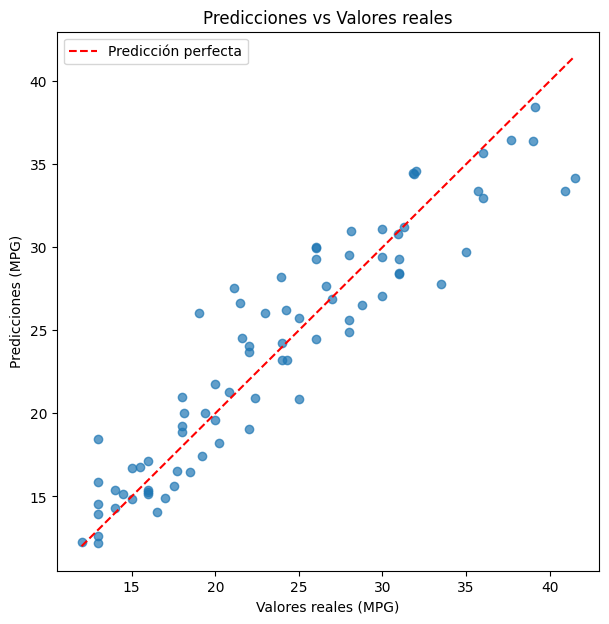

In [121]:
y_pred_all = model.predict(X_test_std).flatten()

plt.figure(figsize=(7, 7))
plt.scatter(y_test, y_pred_all, alpha=0.7)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', label='Predicción perfecta')
plt.xlabel('Valores reales (MPG)')
plt.ylabel('Predicciones (MPG)')
plt.title('Predicciones vs Valores reales')
plt.legend();

Parece que nuestro modelo predice razonablemente bien. Echemos un vistazo a la distribución de errores.

Representa los residuos en un histograma

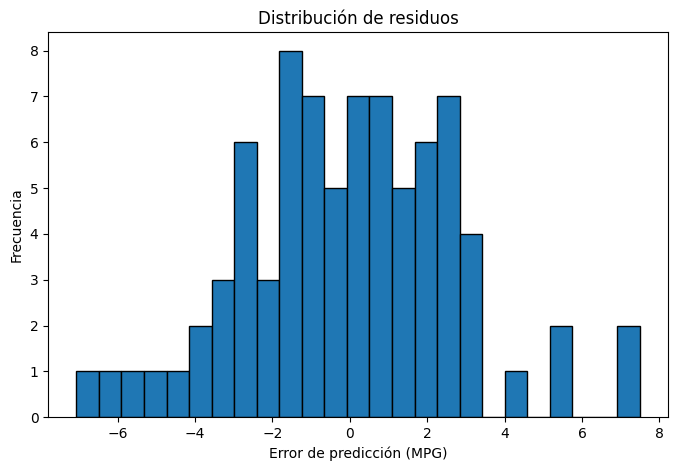

In [122]:
errores = y_test - y_pred_all

plt.figure(figsize=(8, 5))
plt.hist(errores, bins=25, edgecolor='black')
plt.xlabel('Error de predicción (MPG)')
plt.ylabel('Frecuencia')
plt.title('Distribución de residuos');

No es del todo gaussiano, pero podríamos esperar eso porque el número de muestras es muy pequeño.

Guarda tu modelo en un archivo.

In [123]:
model.save('modelo_mpg.keras')

In [124]:
imported_model = keras.models.load_model("modelo_mpg.keras")
imported_model

<Sequential name=sequential, built=True>

## Conclusion

El modelo de regresión predice el consumo (MPG) con un margen de error aceptable. El gráfico de dispersión indica que las predicciones se aproximan bastante a la predicción. Los residuos se distribuyen en torno a cero, lo que sugiere que no existe sesgo sistemático